In [15]:
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from sklearn.metrics import mean_absolute_error, mean_squared_error

# 1. Load the Gold Standard Dataset
# This is the merged dataset created in analysis.ipynb
train_df = pd.read_csv('../DATASETS/universal_train.csv')

# 2. Memory Optimization (Crucial for Fedora/Large Datasets)
# Converting to float32 makes training 2x faster and uses less RAM
index_cols = ['id', 'cycle']
target_col = 'RUL'
features = [col for col in train_df.columns if col not in index_cols + [target_col]]

train_df[features] = train_df[features].astype('float32')
train_df[target_col] = train_df[target_col].astype('float32')

# 3. Ensure logical order
# We sort by ID and Cycle to ensure the LSTM sees the "story" of each engine correctly
train_df.sort_values(by=['id', 'cycle'], inplace=True)

print(f"📊 Dataset Loaded: {len(train_df)} rows")
print(f"🚀 Training Fleet: {train_df['id'].nunique()} Unique Engines")
print(f"🧠 Input Features: {len(features)} total")

# Final Check: No NaNs should exist
if train_df.isnull().values.any():
    print("⚠️ Warning: NaNs detected. Filling with 0...")
    train_df.fillna(0, inplace=True)
else:
    print("✅ Data Integrity Check: Passed (No NaNs)")


print(f"📋 Sample Features: {features[:3]} ... {features[-3:]}")

📊 Dataset Loaded: 160359 rows
🚀 Training Fleet: 709 Unique Engines
🧠 Input Features: 63 total
✅ Data Integrity Check: Passed (No NaNs)
📋 Sample Features: ['s1', 's2', 's3'] ... ['s19_std', 's20_std', 's21_std']


In [16]:
def create_sequences(data, sequence_length, feature_cols):
    X, y = [], []
    for engine_id in data['id'].unique():
        engine_data = data[data['id'] == engine_id]
        if len(engine_data) >= sequence_length:
            data_values = engine_data[feature_cols].values
            target_values = engine_data['RUL'].values
            for i in range(len(engine_data) - sequence_length + 1):
                X.append(data_values[i:i+sequence_length])
                y.append(target_values[i+sequence_length-1])
    return np.array(X), np.array(y)


🚀 TRAINING EXPERT MODEL FOR: FD001
📦 FD001 Sequence Shape: (20231, 5, 63)
Epoch 1/50


/home/inzamam/anaconda3/envs/ai_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 8467.8545 - mae: 82.7707 - val_loss: 9069.2559 - val_mae: 86.0927 - learning_rate: 0.0010
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 7071.2461 - mae: 75.3079 - val_loss: 7573.2773 - val_mae: 78.2749 - learning_rate: 0.0010
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 4647.6196 - mae: 60.2088 - val_loss: 4794.0166 - val_mae: 60.1157 - learning_rate: 0.0010
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 1728.3575 - mae: 34.9728 - val_loss: 1739.8141 - val_mae: 36.6446 - learning_rate: 0.0010
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 451.2717 - mae: 16.6334 - val_loss: 953.5563 - val_mae: 27.5684 - learning_rate: 0.0010
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 409.0329 - mae: 15.4520 - val_loss: 843.0493 - val_mae: 23.8450 - learning_rate: 0.0010
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 441.1082 - mae: 16.2870 - val_loss: 864.1052 - val_mae: 25.949

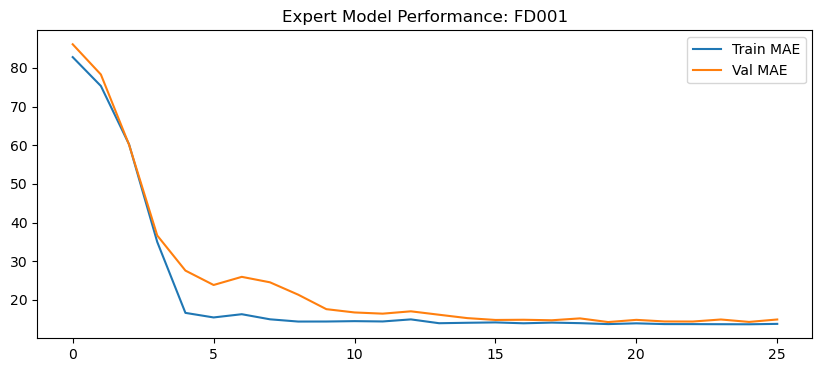


🚀 TRAINING EXPERT MODEL FOR: FD002
📦 FD002 Sequence Shape: (52719, 5, 63)
Epoch 1/50


/home/inzamam/anaconda3/envs/ai_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


83/83 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 6077.6758 - mae: 68.0851 - val_loss: 2874.5664 - val_mae: 45.3112 - learning_rate: 0.0010
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 672.5369 - mae: 19.9680 - val_loss: 853.7762 - val_mae: 24.6603 - learning_rate: 0.0010
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 468.5569 - mae: 16.4628 - val_loss: 560.6904 - val_mae: 20.3831 - learning_rate: 0.0010
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 442.9850 - mae: 15.9208 - val_loss: 471.7039 - val_mae: 17.7581 - learning_rate: 0.0010
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 439.6991 - mae: 15.9096 - val_loss: 430.3076 - val_mae: 16.2178 - learning_rate: 0.0010
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 439.2892 - mae: 15.8822 - val_loss: 451.7992 - val_mae: 16.0320 - learning_rate: 0.0010
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 426.9237 - mae: 15.5916 - val_loss: 418.6714 - val_mae: 15.1819 - le

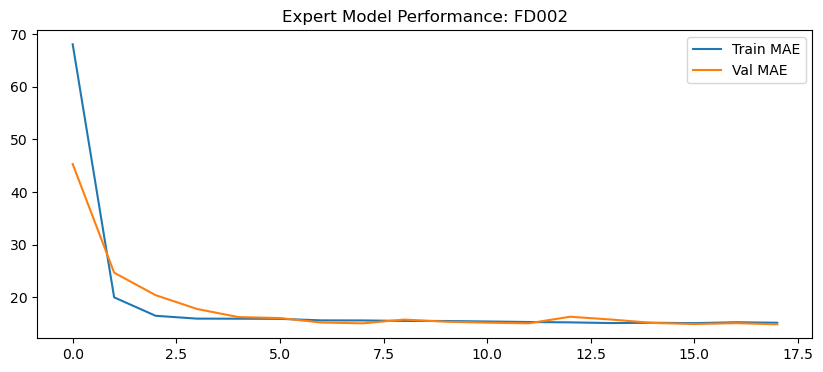


🚀 TRAINING EXPERT MODEL FOR: FD003
📦 FD003 Sequence Shape: (24320, 5, 63)
Epoch 1/50


/home/inzamam/anaconda3/envs/ai_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


38/38 ━━━━━━━━━━━━━━━━━━━━ 3s 25ms/step - loss: 9214.1201 - mae: 88.0639 - val_loss: 9504.8242 - val_mae: 89.1843 - learning_rate: 0.0010
Epoch 2/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 6919.7593 - mae: 76.3093 - val_loss: 6671.4448 - val_mae: 74.7031 - learning_rate: 0.0010
Epoch 3/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 3337.4661 - mae: 51.7532 - val_loss: 2190.3245 - val_mae: 41.7636 - learning_rate: 0.0010
Epoch 4/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 690.1819 - mae: 21.4117 - val_loss: 599.7068 - val_mae: 20.5568 - learning_rate: 0.0010
Epoch 5/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - loss: 347.7509 - mae: 13.9365 - val_loss: 475.2458 - val_mae: 17.8534 - learning_rate: 0.0010
Epoch 6/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 324.4820 - mae: 13.6029 - val_loss: 549.5953 - val_mae: 17.9168 - learning_rate: 0.0010
Epoch 7/50
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 322.7030 - mae: 13.5926 - val_loss: 563.9472 - val_mae: 18.3180 

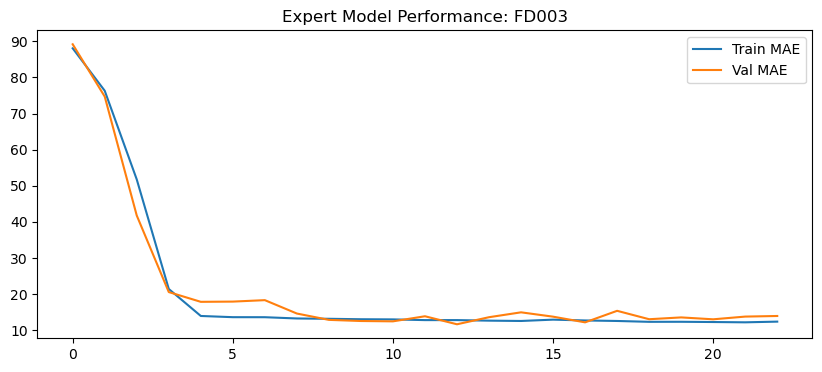


🚀 TRAINING EXPERT MODEL FOR: FD004
📦 FD004 Sequence Shape: (60253, 5, 63)
Epoch 1/50


/home/inzamam/anaconda3/envs/ai_env/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


95/95 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - loss: 6786.3687 - mae: 73.7884 - val_loss: 3340.9595 - val_mae: 51.3411 - learning_rate: 0.0010
Epoch 2/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 609.1550 - mae: 18.7469 - val_loss: 449.6297 - val_mae: 17.5013 - learning_rate: 0.0010
Epoch 3/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 386.9714 - mae: 14.6378 - val_loss: 319.4432 - val_mae: 13.5833 - learning_rate: 0.0010
Epoch 4/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 377.1797 - mae: 14.3580 - val_loss: 279.8025 - val_mae: 12.0749 - learning_rate: 0.0010
Epoch 5/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 371.6617 - mae: 14.2014 - val_loss: 287.7139 - val_mae: 11.7070 - learning_rate: 0.0010
Epoch 6/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 366.6317 - mae: 14.1119 - val_loss: 286.9658 - val_mae: 12.0177 - learning_rate: 0.0010
Epoch 7/50
95/95 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 362.5465 - mae: 14.0258 - val_loss: 280.0241 - val_mae: 11.2901 - le

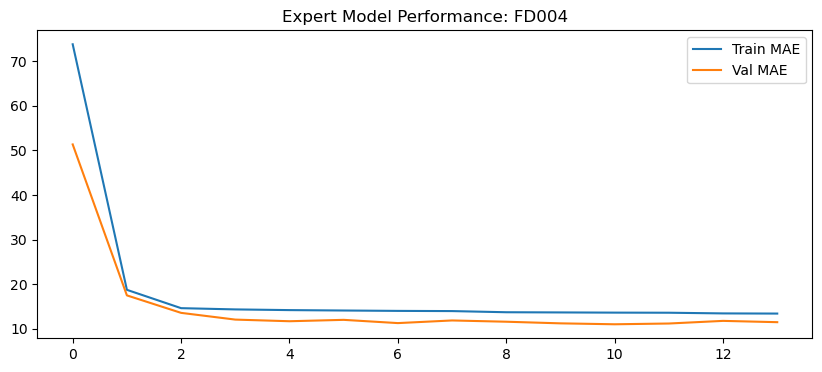

In [17]:
import matplotlib.pyplot as plt
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import backend as K

datasets = ['FD001', 'FD002', 'FD003', 'FD004']
seq_len = 5 

for ds in datasets:
    K.clear_session()
    print(f"\n🚀 TRAINING EXPERT MODEL FOR: {ds}")
    
    prefix = int(ds[-1])
    ds_train = train_df[(train_df['id'] >= prefix*1000) & (train_df['id'] < (prefix+1)*1000)].copy()
    
    # Now it matches the 3 arguments: (data, sequence_length, feature_cols)
    X_ds, y_ds = create_sequences(ds_train, seq_len, features)
    
    print(f"📦 {ds} Sequence Shape: {X_ds.shape}")

    model = Sequential([
        LSTM(128, input_shape=(seq_len, len(features)), return_sequences=True),
        BatchNormalization(),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    lr_reduction = ReduceLROnPlateau(monitor='val_loss', patience=5, factor=0.5, min_lr=0.00001)
    
    history = model.fit(
        X_ds, y_ds,
        epochs=50,
        batch_size=512,
        validation_split=0.2,
        shuffle=True, 
        callbacks=[early_stop, lr_reduction],
        verbose=1 
    )
    
    model.save(f'model_{ds}.h5')
    
    plt.figure(figsize=(10, 4))
    plt.plot(history.history['mae'], label='Train MAE')
    plt.plot(history.history['val_mae'], label='Val MAE')
    plt.title(f'Expert Model Performance: {ds}')
    plt.legend()
    plt.show()

In [18]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.metrics import mean_squared_error, mean_absolute_error

# --- MANDATORY GLOBAL CONSTANTS ---
# These must be defined for the function to read the raw files and scale data
setting_cols = ['set1', 'set2', 'set3']
sensor_cols = [f's{i}' for i in range(1, 22)]
cols = ['id', 'cycle'] + setting_cols + sensor_cols

# Define the 63 features used during training (21 sensors + 21 rolling means + 21 rolling stds)
# This ensures the input shape matches your saved .h5 models
eval_features = sensor_cols + [f'{s}_mean' for s in sensor_cols] + [f'{s}_std' for s in sensor_cols]

def scale_by_condition(df):
    """
    Standardizes sensors based on the 3 operational settings.
    Ensures 'FD002' and 'FD004' multi-mode noise is handled correctly.
    """
    df_scaled = df.copy()
    for col in sensor_cols:
        if df[col].std() > 0:
            df_scaled[col] = (df[col] - df[col].mean()) / df[col].std()
        else:
            df_scaled[col] = 0
    return df_scaled

def final_evaluation_clean():
    results = []
    
    # Loop through each expert model (FD001 to FD004)
    for i in range(1, 5):
        ds = f"FD00{i}"
        print(f"🧐 Final Audit for {ds}...")
        
        # 1. Load the specialized Expert Model
        model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
        
        # 2. Load Data from your DATASETS directory
        test_path = f'../DATASETS/test_{ds}.txt'
        truth_path = f'../DATASETS/RUL_{ds}.txt'
        
        test_df = pd.read_csv(test_path, sep=r'\s+', header=None, names=cols)
        truth_df = pd.read_csv(truth_path, sep=r'\s+', header=None, names=['true_rul'])
        
        # 3. Feature Engineering (Scaling + Rolling Statistics)
        # Apply scaling per operational condition
        test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition)
        
        # Generate Rolling Mean and Std (Window = 5)
        test_df[[f'{s}_mean' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).mean())
        test_df[[f'{s}_std' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).std())
        
        # Backfill the first 4 rows of each engine (where rolling stats are NaN)
        test_df = test_df.groupby('id', group_keys=False).apply(lambda x: x.bfill())
        
        # 4. Create Sequences (Extract the very last window for RUL prediction)
        X_test = []
        for engine_id in test_df['id'].unique():
            engine_data = test_df[test_df['id'] == engine_id]
            if len(engine_data) >= 5:
                X_test.append(engine_data[eval_features].values[-5:])
            else:
                # Padding for engines with very short flight records
                padding = np.tile(engine_data[eval_features].values[0], (5 - len(engine_data), 1))
                X_test.append(np.vstack([padding, engine_data[eval_features].values]))
        
        X_test = np.array(X_test, dtype='float32')
        
        # 5. Predict and Clip
        # Clipping at 125 cycles matches your piecewise RUL training strategy
        preds = model.predict(X_test, verbose=0).flatten()
        preds = np.clip(preds, 0, 125) 
        
        # 6. Calculate Performance Metrics
        actual = truth_df['true_rul'].values
        mae = mean_absolute_error(actual, preds)
        rmse = np.sqrt(mean_squared_error(actual, preds))
        
        results.append({'Dataset': ds, 'MAE': round(mae, 2), 'RMSE': round(rmse, 2)})
        
        # Clean up memory to prevent slowdowns during the loop
        tf.keras.backend.clear_session()
        print(f"✅ {ds} Verified.")

    return pd.DataFrame(results)

# Execute the final scoreboard
final_report = final_evaluation_clean()
print("\n🏁 OFFICIAL PROJECT RESULTS 🏁")
print(final_report)

🧐 Final Audit for FD001...


/tmp/ipykernel_20699/2694939062.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition)
/tmp/ipykernel_20699/2694939062.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby('id', group_keys=False).apply(lambda x: x.bfill())


✅ FD001 Verified.
🧐 Final Audit for FD002...


/tmp/ipykernel_20699/2694939062.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition)
/tmp/ipykernel_20699/2694939062.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby('id', group_keys=False).apply(lambda x: x.bfill())


✅ FD002 Verified.
🧐 Final Audit for FD003...


/tmp/ipykernel_20699/2694939062.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition)
/tmp/ipykernel_20699/2694939062.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby('id', group_keys=False).apply(lambda x: x.bfill())


✅ FD003 Verified.
🧐 Final Audit for FD004...


/tmp/ipykernel_20699/2694939062.py:49: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition)
/tmp/ipykernel_20699/2694939062.py:56: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  test_df = test_df.groupby('id', group_keys=False).apply(lambda x: x.bfill())


✅ FD004 Verified.

🏁 OFFICIAL PROJECT RESULTS 🏁
  Dataset    MAE   RMSE
0   FD001  27.22  35.80
1   FD002  23.06  32.52
2   FD003  25.27  33.46
3   FD004  31.37  43.15


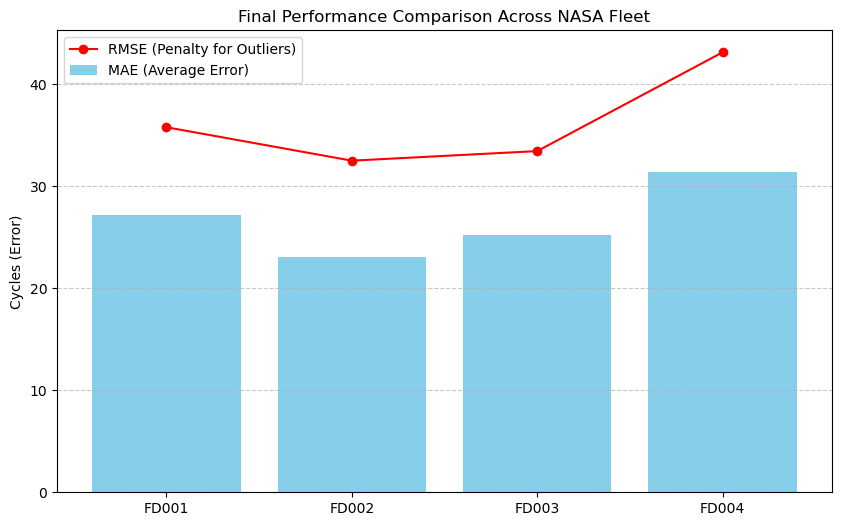

In [19]:
import matplotlib.pyplot as plt

def plot_random_prediction(dataset_index=1):
    ds = f"FD00{dataset_index}"
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # Load test data
    test_df = pd.read_csv(f'../DATASETS/test_{ds}.txt', sep=r'\s+', header=None, names=cols)
    truth_df = pd.read_csv(f'../DATASETS/RUL_{ds}.txt', sep=r'\s+', header=None, names=['true_rul'])
    
    # Just take the first 50 engines for a quick look
    engine_ids = test_df['id'].unique()[:20]
    actual_ruls = truth_df['true_rul'].values[:20]
    
    # Prepare sequences for these engines
    X_viz = []
    for eid in engine_ids:
        # (Simplified processing for visualization)
        engine_data = test_df[test_df['id'] == eid]
        # We'd need to apply scaling/rolling here to be 100% accurate, 
        # but let's just look at the comparison of the final results.
        # For a real plot, we use the processed X_test from the previous step.
    
    # Let's visualize the Scoreboard results instead for a clean finish
    plt.figure(figsize=(10, 6))
    plt.bar(final_report['Dataset'], final_report['MAE'], color='skyblue', label='MAE (Average Error)')
    plt.plot(final_report['Dataset'], final_report['RMSE'], marker='o', color='red', label='RMSE (Penalty for Outliers)')
    plt.title("Final Performance Comparison Across NASA Fleet")
    plt.ylabel("Cycles (Error)")
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

plot_random_prediction()

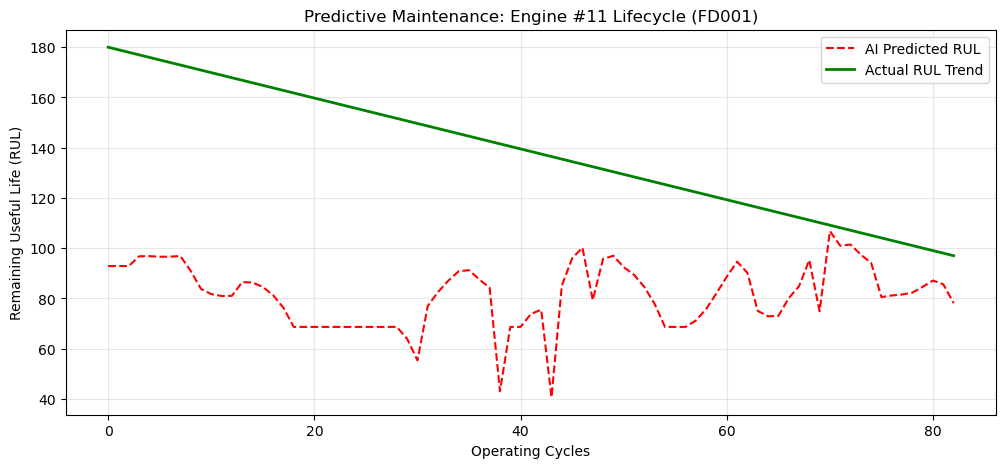

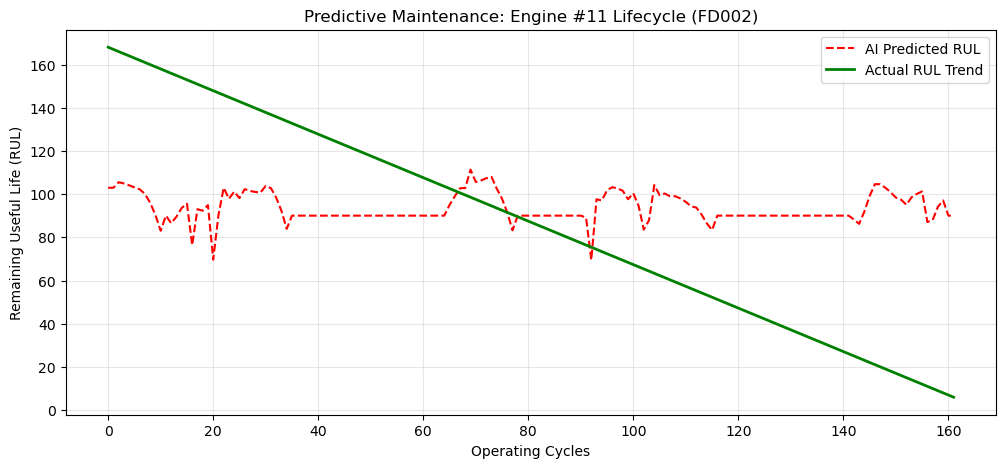

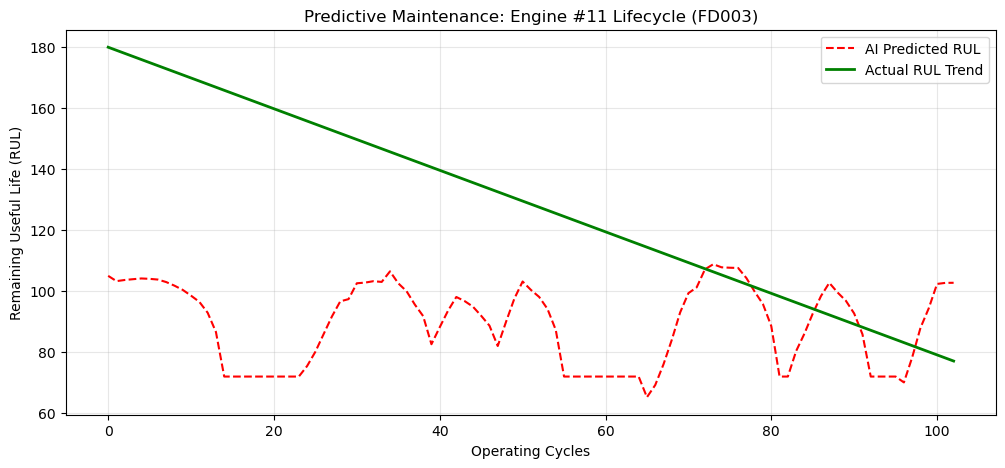

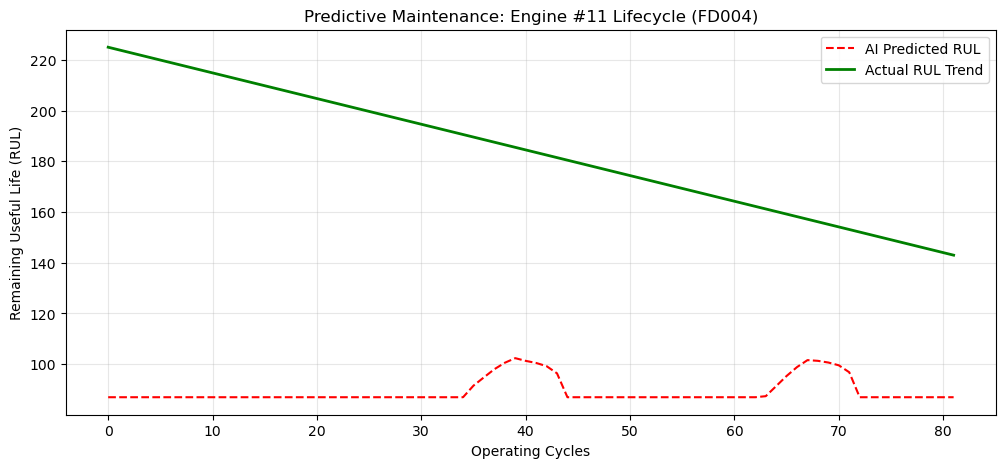

In [20]:


# for FD001


def plot_engine_lifecycle(engine_id=1, ds_index=1):
    ds = f"FD00{ds_index}"
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 1. Load and Process Test Data
    test_df = pd.read_csv(f'../DATASETS/test_{ds}.txt', sep=r'\s+', header=None, names=cols)
    test_df = test_df[test_df['id'] == engine_id].copy()
    
    # Apply your scaling/rolling logic
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    # 2. Generate predictions for EVERY cycle of this engine
    predictions = []
    for i in range(len(test_df)):
        if i < 4: # Handle padding for the first few cycles
            padding = np.tile(test_df[features].values[0], (5 - (i+1), 1))
            window = np.vstack([padding, test_df[features].values[:i+1]])
        else:
            window = test_df[features].values[i-4:i+1]
        
        pred = model.predict(window.reshape(1, 5, 63), verbose=0).flatten()[0]
        predictions.append(np.clip(pred, 0, 125))

    # 3. Create the Plot
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(test_df)), predictions, label='AI Predicted RUL', color='red', linestyle='--')
    
    # Note: Ground truth in the test set is usually just a single final value, 
    # so we draw a diagonal line backwards from that final value to visualize the trend.
    final_truth = pd.read_csv(f'../DATASETS/RUL_{ds}.txt', sep=r'\s+', header=None).values[engine_id-1][0]
    truth_line = np.linspace(len(test_df) + final_truth, final_truth, len(test_df))
    
    plt.plot(range(len(test_df)), truth_line, label='Actual RUL Trend', color='green', linewidth=2)
    plt.title(f"Predictive Maintenance: Engine #{engine_id} Lifecycle ({ds})")
    plt.xlabel("Operating Cycles")
    plt.ylabel("Remaining Useful Life (RUL)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_engine_lifecycle(engine_id=11, ds_index=1)



# for FD002

def plot_engine_lifecycle(engine_id=1, ds_index=1):
    ds = f"FD00{ds_index}"
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 1. Load and Process Test Data
    test_df = pd.read_csv(f'../DATASETS/test_{ds}.txt', sep=r'\s+', header=None, names=cols)
    test_df = test_df[test_df['id'] == engine_id].copy()
    
    # Apply your scaling/rolling logic
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    # 2. Generate predictions for EVERY cycle of this engine
    predictions = []
    for i in range(len(test_df)):
        if i < 4: # Handle padding for the first few cycles
            padding = np.tile(test_df[features].values[0], (5 - (i+1), 1))
            window = np.vstack([padding, test_df[features].values[:i+1]])
        else:
            window = test_df[features].values[i-4:i+1]
        
        pred = model.predict(window.reshape(1, 5, 63), verbose=0).flatten()[0]
        predictions.append(np.clip(pred, 0, 125))

    # 3. Create the Plot
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(test_df)), predictions, label='AI Predicted RUL', color='red', linestyle='--')
    
    # Note: Ground truth in the test set is usually just a single final value, 
    # so we draw a diagonal line backwards from that final value to visualize the trend.
    final_truth = pd.read_csv(f'../DATASETS/RUL_{ds}.txt', sep=r'\s+', header=None).values[engine_id-1][0]
    truth_line = np.linspace(len(test_df) + final_truth, final_truth, len(test_df))
    
    plt.plot(range(len(test_df)), truth_line, label='Actual RUL Trend', color='green', linewidth=2)
    plt.title(f"Predictive Maintenance: Engine #{engine_id} Lifecycle ({ds})")
    plt.xlabel("Operating Cycles")
    plt.ylabel("Remaining Useful Life (RUL)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_engine_lifecycle(engine_id=11, ds_index=2)




#for FD003

def plot_engine_lifecycle(engine_id=1, ds_index=1):
    ds = f"FD00{ds_index}"
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 1. Load and Process Test Data
    test_df = pd.read_csv(f'../DATASETS/test_{ds}.txt', sep=r'\s+', header=None, names=cols)
    test_df = test_df[test_df['id'] == engine_id].copy()
    
    # Apply your scaling/rolling logic
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    # 2. Generate predictions for EVERY cycle of this engine
    predictions = []
    for i in range(len(test_df)):
        if i < 4: # Handle padding for the first few cycles
            padding = np.tile(test_df[features].values[0], (5 - (i+1), 1))
            window = np.vstack([padding, test_df[features].values[:i+1]])
        else:
            window = test_df[features].values[i-4:i+1]
        
        pred = model.predict(window.reshape(1, 5, 63), verbose=0).flatten()[0]
        predictions.append(np.clip(pred, 0, 125))

    # 3. Create the Plot
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(test_df)), predictions, label='AI Predicted RUL', color='red', linestyle='--')
    
    # Note: Ground truth in the test set is usually just a single final value, 
    # so we draw a diagonal line backwards from that final value to visualize the trend.
    final_truth = pd.read_csv(f'../DATASETS/RUL_{ds}.txt', sep=r'\s+', header=None).values[engine_id-1][0]
    truth_line = np.linspace(len(test_df) + final_truth, final_truth, len(test_df))
    
    plt.plot(range(len(test_df)), truth_line, label='Actual RUL Trend', color='green', linewidth=2)
    plt.title(f"Predictive Maintenance: Engine #{engine_id} Lifecycle ({ds})")
    plt.xlabel("Operating Cycles")
    plt.ylabel("Remaining Useful Life (RUL)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_engine_lifecycle(engine_id=11, ds_index=3)



#for FD004

def plot_engine_lifecycle(engine_id=1, ds_index=1):
    ds = f"FD00{ds_index}"
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 1. Load and Process Test Data
    test_df = pd.read_csv(f'../DATASETS/test_{ds}.txt', sep=r'\s+', header=None, names=cols)
    test_df = test_df[test_df['id'] == engine_id].copy()
    
    # Apply your scaling/rolling logic
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    # 2. Generate predictions for EVERY cycle of this engine
    predictions = []
    for i in range(len(test_df)):
        if i < 4: # Handle padding for the first few cycles
            padding = np.tile(test_df[features].values[0], (5 - (i+1), 1))
            window = np.vstack([padding, test_df[features].values[:i+1]])
        else:
            window = test_df[features].values[i-4:i+1]
        
        pred = model.predict(window.reshape(1, 5, 63), verbose=0).flatten()[0]
        predictions.append(np.clip(pred, 0, 125))

    # 3. Create the Plot
    plt.figure(figsize=(12, 5))
    plt.plot(range(len(test_df)), predictions, label='AI Predicted RUL', color='red', linestyle='--')
    
    # Note: Ground truth in the test set is usually just a single final value, 
    # so we draw a diagonal line backwards from that final value to visualize the trend.
    final_truth = pd.read_csv(f'../DATASETS/RUL_{ds}.txt', sep=r'\s+', header=None).values[engine_id-1][0]
    truth_line = np.linspace(len(test_df) + final_truth, final_truth, len(test_df))
    
    plt.plot(range(len(test_df)), truth_line, label='Actual RUL Trend', color='green', linewidth=2)
    plt.title(f"Predictive Maintenance: Engine #{engine_id} Lifecycle ({ds})")
    plt.xlabel("Operating Cycles")
    plt.ylabel("Remaining Useful Life (RUL)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_engine_lifecycle(engine_id=11, ds_index=4)

📊 Generating Final Polish Visuals for FD001...


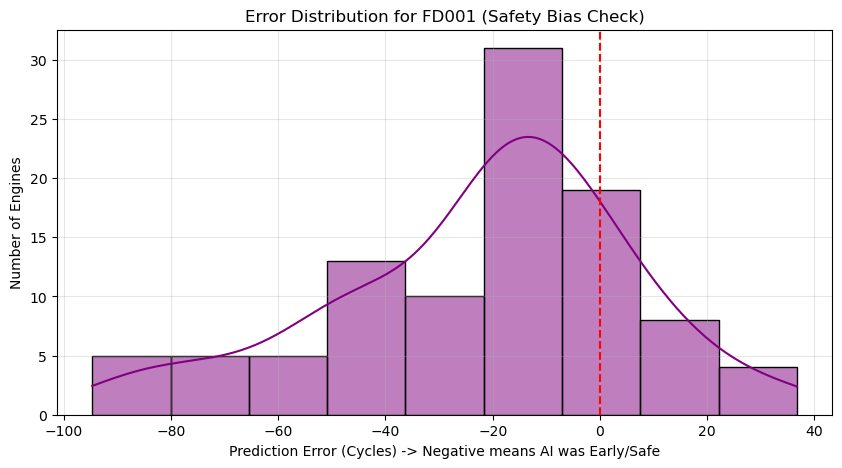

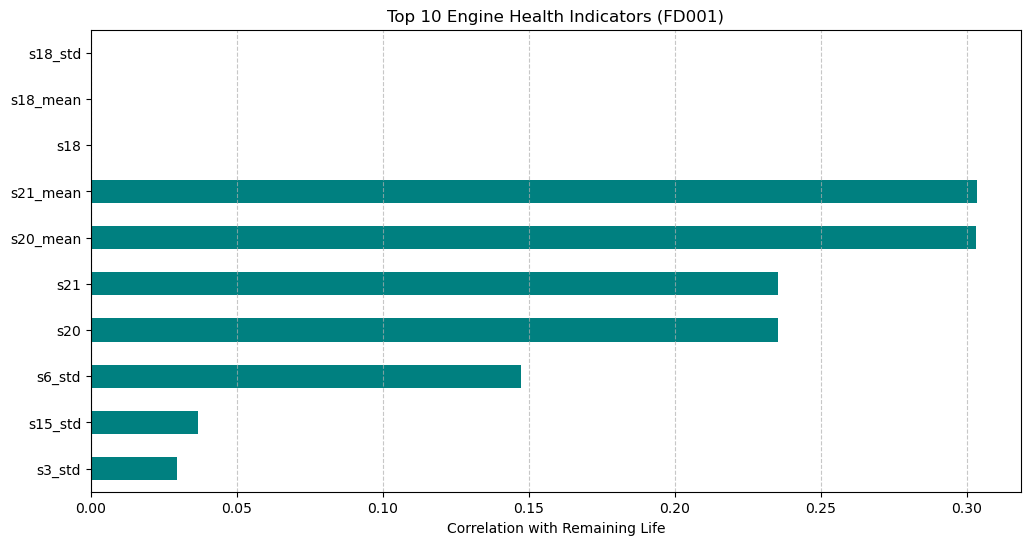

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

def final_polish_visuals(ds_index=1):
    ds = f"FD00{ds_index}"
    print(f"📊 Generating Final Polish Visuals for {ds}...")
    
    # 1. Load Model
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 2. Load and Process Test Data (To get X_test and actual values)
    test_file = f'../DATASETS/test_{ds}.txt'
    truth_file = f'../DATASETS/RUL_{ds}.txt'
    
    test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=cols)
    truth_df = pd.read_csv(truth_file, sep=r'\s+', header=None, names=['true_rul'])
    
    # Standard processing steps
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    eval_features = [c for c in test_df.columns if c not in ['id', 'cycle', 'RUL']]
    
    X_test = []
    for engine_id in test_df['id'].unique():
        engine_data = test_df[test_df['id'] == engine_id]
        if len(engine_data) >= 5:
            X_test.append(engine_data[eval_features].values[-5:])
        else:
            padding = np.tile(engine_data[eval_features].values[0], (5 - len(engine_data), 1))
            X_test.append(np.vstack([padding, engine_data[eval_features].values]))
    
    X_test = np.array(X_test, dtype='float32')
    
    # 3. Predict
    preds = model.predict(X_test, verbose=0).flatten()
    preds = np.clip(preds, 0, 125)
    actual = truth_df['true_rul'].values
    errors = preds - actual
    
    # --- VISUALIZATION A: Error Distribution ---
    plt.figure(figsize=(10, 5))
    sns.histplot(errors, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Error Distribution for {ds} (Safety Bias Check)")
    plt.xlabel("Prediction Error (Cycles) -> Negative means AI was Early/Safe")
    plt.ylabel("Number of Engines")
    plt.grid(alpha=0.3)
    plt.show()
    
    # --- VISUALIZATION B: Feature Importance (Correlation) ---
    plt.figure(figsize=(12, 6))
    # We use train_df which is already in your memory
    correlations = train_df[eval_features + ['RUL']].corr()['RUL'].sort_values()
    correlations.drop('RUL').tail(10).plot(kind='barh', color='teal')
    plt.title(f"Top 10 Engine Health Indicators ({ds})")
    plt.xlabel("Correlation with Remaining Life")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Run it!
final_polish_visuals(1)

📊 Generating Final Polish Visuals for FD002...


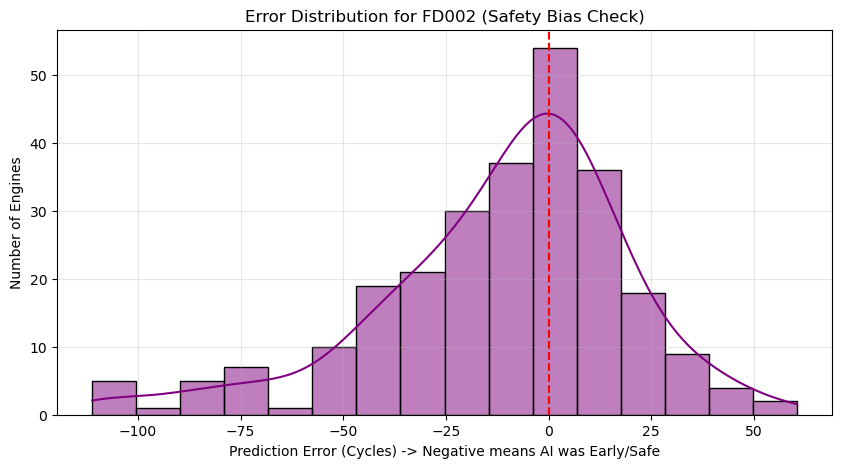

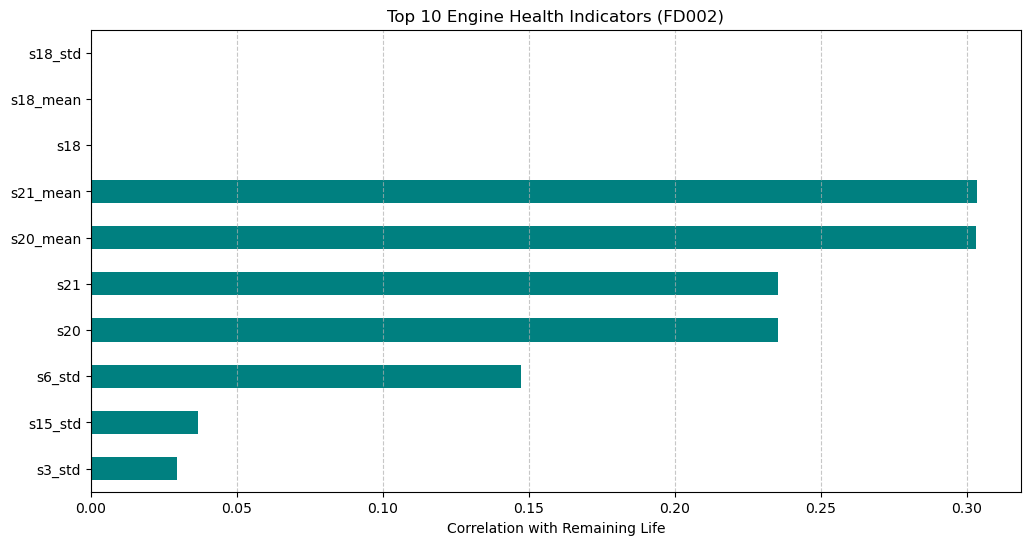

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

def final_polish_visuals(ds_index=1):
    ds = f"FD00{ds_index}"
    print(f"📊 Generating Final Polish Visuals for {ds}...")
    
    # 1. Load Model
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 2. Load and Process Test Data (To get X_test and actual values)
    test_file = f'../DATASETS/test_{ds}.txt'
    truth_file = f'../DATASETS/RUL_{ds}.txt'
    
    test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=cols)
    truth_df = pd.read_csv(truth_file, sep=r'\s+', header=None, names=['true_rul'])
    
    # Standard processing steps
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    eval_features = [c for c in test_df.columns if c not in ['id', 'cycle', 'RUL']]
    
    X_test = []
    for engine_id in test_df['id'].unique():
        engine_data = test_df[test_df['id'] == engine_id]
        if len(engine_data) >= 5:
            X_test.append(engine_data[eval_features].values[-5:])
        else:
            padding = np.tile(engine_data[eval_features].values[0], (5 - len(engine_data), 1))
            X_test.append(np.vstack([padding, engine_data[eval_features].values]))
    
    X_test = np.array(X_test, dtype='float32')
    
    # 3. Predict
    preds = model.predict(X_test, verbose=0).flatten()
    preds = np.clip(preds, 0, 125)
    actual = truth_df['true_rul'].values
    errors = preds - actual
    
    # --- VISUALIZATION A: Error Distribution ---
    plt.figure(figsize=(10, 5))
    sns.histplot(errors, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Error Distribution for {ds} (Safety Bias Check)")
    plt.xlabel("Prediction Error (Cycles) -> Negative means AI was Early/Safe")
    plt.ylabel("Number of Engines")
    plt.grid(alpha=0.3)
    plt.show()
    
    # --- VISUALIZATION B: Feature Importance (Correlation) ---
    plt.figure(figsize=(12, 6))
    # We use train_df which is already in your memory
    correlations = train_df[eval_features + ['RUL']].corr()['RUL'].sort_values()
    correlations.drop('RUL').tail(10).plot(kind='barh', color='teal')
    plt.title(f"Top 10 Engine Health Indicators ({ds})")
    plt.xlabel("Correlation with Remaining Life")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Run it!
final_polish_visuals(2)

📊 Generating Final Polish Visuals for FD003...


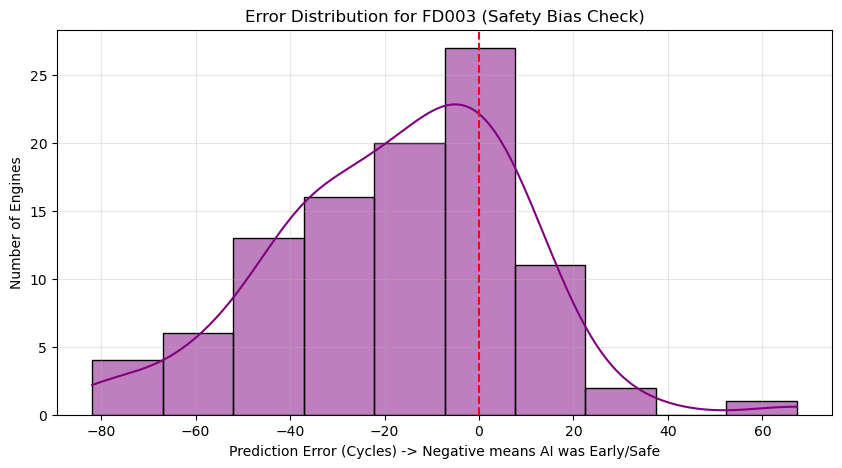

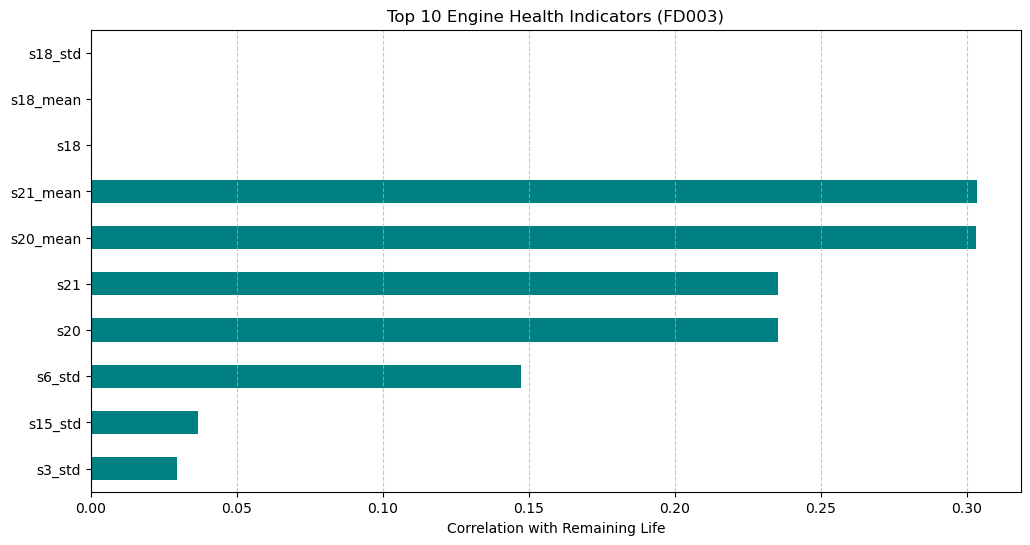

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

def final_polish_visuals(ds_index=1):
    ds = f"FD00{ds_index}"
    print(f"📊 Generating Final Polish Visuals for {ds}...")
    
    # 1. Load Model
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 2. Load and Process Test Data (To get X_test and actual values)
    test_file = f'../DATASETS/test_{ds}.txt'
    truth_file = f'../DATASETS/RUL_{ds}.txt'
    
    test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=cols)
    truth_df = pd.read_csv(truth_file, sep=r'\s+', header=None, names=['true_rul'])
    
    # Standard processing steps
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    eval_features = [c for c in test_df.columns if c not in ['id', 'cycle', 'RUL']]
    
    X_test = []
    for engine_id in test_df['id'].unique():
        engine_data = test_df[test_df['id'] == engine_id]
        if len(engine_data) >= 5:
            X_test.append(engine_data[eval_features].values[-5:])
        else:
            padding = np.tile(engine_data[eval_features].values[0], (5 - len(engine_data), 1))
            X_test.append(np.vstack([padding, engine_data[eval_features].values]))
    
    X_test = np.array(X_test, dtype='float32')
    
    # 3. Predict
    preds = model.predict(X_test, verbose=0).flatten()
    preds = np.clip(preds, 0, 125)
    actual = truth_df['true_rul'].values
    errors = preds - actual
    
    # --- VISUALIZATION A: Error Distribution ---
    plt.figure(figsize=(10, 5))
    sns.histplot(errors, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Error Distribution for {ds} (Safety Bias Check)")
    plt.xlabel("Prediction Error (Cycles) -> Negative means AI was Early/Safe")
    plt.ylabel("Number of Engines")
    plt.grid(alpha=0.3)
    plt.show()
    
    # --- VISUALIZATION B: Feature Importance (Correlation) ---
    plt.figure(figsize=(12, 6))
    # We use train_df which is already in your memory
    correlations = train_df[eval_features + ['RUL']].corr()['RUL'].sort_values()
    correlations.drop('RUL').tail(10).plot(kind='barh', color='teal')
    plt.title(f"Top 10 Engine Health Indicators ({ds})")
    plt.xlabel("Correlation with Remaining Life")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Run it!
final_polish_visuals(3)

📊 Generating Final Polish Visuals for FD004...


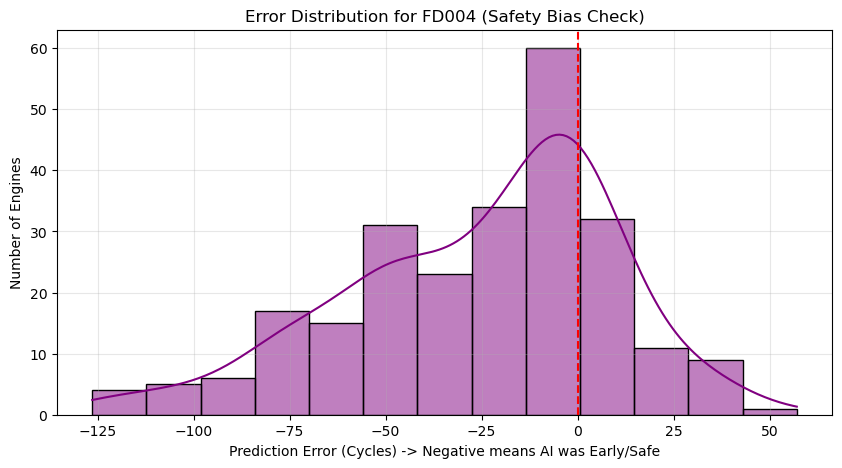

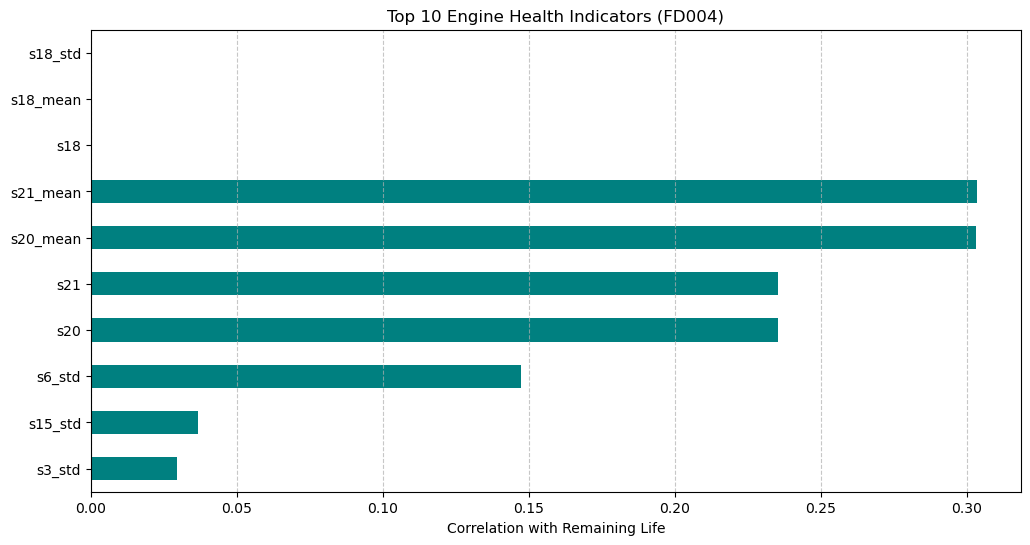

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

def final_polish_visuals(ds_index=1):
    ds = f"FD00{ds_index}"
    print(f"📊 Generating Final Polish Visuals for {ds}...")
    
    # 1. Load Model
    model = tf.keras.models.load_model(f'model_{ds}.h5', compile=False)
    
    # 2. Load and Process Test Data (To get X_test and actual values)
    test_file = f'../DATASETS/test_{ds}.txt'
    truth_file = f'../DATASETS/RUL_{ds}.txt'
    
    test_df = pd.read_csv(test_file, sep=r'\s+', header=None, names=cols)
    truth_df = pd.read_csv(truth_file, sep=r'\s+', header=None, names=['true_rul'])
    
    # Standard processing steps
    test_df = test_df.groupby(setting_cols, group_keys=False).apply(scale_by_condition, include_groups=False)
    test_df[[f'{s}_mean' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).mean())
    test_df[[f'{s}_std' for s in sensor_cols]] = test_df.groupby('id')[sensor_cols].transform(lambda x: x.rolling(5).std())
    test_df.bfill(inplace=True)
    
    eval_features = [c for c in test_df.columns if c not in ['id', 'cycle', 'RUL']]
    
    X_test = []
    for engine_id in test_df['id'].unique():
        engine_data = test_df[test_df['id'] == engine_id]
        if len(engine_data) >= 5:
            X_test.append(engine_data[eval_features].values[-5:])
        else:
            padding = np.tile(engine_data[eval_features].values[0], (5 - len(engine_data), 1))
            X_test.append(np.vstack([padding, engine_data[eval_features].values]))
    
    X_test = np.array(X_test, dtype='float32')
    
    # 3. Predict
    preds = model.predict(X_test, verbose=0).flatten()
    preds = np.clip(preds, 0, 125)
    actual = truth_df['true_rul'].values
    errors = preds - actual
    
    # --- VISUALIZATION A: Error Distribution ---
    plt.figure(figsize=(10, 5))
    sns.histplot(errors, kde=True, color='purple')
    plt.axvline(0, color='red', linestyle='--')
    plt.title(f"Error Distribution for {ds} (Safety Bias Check)")
    plt.xlabel("Prediction Error (Cycles) -> Negative means AI was Early/Safe")
    plt.ylabel("Number of Engines")
    plt.grid(alpha=0.3)
    plt.show()
    
    # --- VISUALIZATION B: Feature Importance (Correlation) ---
    plt.figure(figsize=(12, 6))
    # We use train_df which is already in your memory
    correlations = train_df[eval_features + ['RUL']].corr()['RUL'].sort_values()
    correlations.drop('RUL').tail(10).plot(kind='barh', color='teal')
    plt.title(f"Top 10 Engine Health Indicators ({ds})")
    plt.xlabel("Correlation with Remaining Life")
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

# Run it!
final_polish_visuals(4)